# Mini Project: Stroke Prediction
## Notebook 1: Exploratory Data Analysis (EDA)

**รายวิชา:** 344-362 Machine Learning

| หัวข้อ | รายละเอียด |
|---|---|
| ปัญหา | คัดกรองความเสี่ยงโรคหลอดเลือดสมอง (stroke) จากข้อมูลสุขภาพพื้นฐาน |
| ประเภท ML | Binary Classification (`stroke` = 1 เป็น, 0 ไม่เป็น) |
| ไลบรารีหลัก | scikit-learn |
| โน้ตบุ๊กนี้ | สำรวจข้อมูลเพื่อหาปัญหาและเหตุผลสำหรับขั้น Preprocessing (**ยังไม่แก้ข้อมูล**) |
| โน้ตบุ๊กถัดไป | `02_model.ipynb` Preprocessing, สร้างและเปรียบเทียบโมเดล, ประเมินผล |

## 1. Problem Definition

**ปัญหาที่ต้องการแก้:** โรคหลอดเลือดสมองเกิดจากเลือดไปเลี้ยงสมองไม่พอ ทำให้เกิดอัมพาตหรือเสียชีวิตได้
หากคัดกรองผู้ที่มีความเสี่ยงได้ล่วงหน้าจากข้อมูลสุขภาพพื้นฐาน จะช่วยให้ไปพบแพทย์หรือปรับพฤติกรรมได้เร็วขึ้น

**เหตุผลที่เลือกปัญหานี้:** *(✏️ กลุ่มเขียนด้วยคำของตัวเอง)* เช่น เป็นปัญหาสุขภาพที่ใกล้ตัว
และข้อมูลมีความท้าทายเรื่องค่าหายและข้อมูลไม่สมดุล ซึ่งตรงกับเนื้อหาที่เรียน

**ประเภท Machine Learning:** Supervised Learning, **Binary Classification**

## 2. Dataset

- **แหล่งข้อมูล:** fedesoriano, *Stroke Prediction Dataset*, Kaggle *(✏️ ใส่ลิงก์และวันที่ดาวน์โหลด)*
- **จำนวนข้อมูล:** 5,110 แถว, 12 คอลัมน์ (ฟีเจอร์ 10 ตัว + `id` + target)

| ฟีเจอร์ | ความหมาย | ชนิด |
|---|---|---|
| gender | เพศ | หมวดหมู่ |
| age | อายุ (ปี) | ตัวเลข |
| hypertension | เป็นความดันโลหิตสูง (0/1) | binary |
| heart_disease | เป็นโรคหัวใจ (0/1) | binary |
| ever_married | เคยแต่งงาน (Yes/No) | หมวดหมู่ |
| work_type | ประเภทงาน | หมวดหมู่ |
| Residence_type | ที่อยู่อาศัย (Urban/Rural) | หมวดหมู่ |
| avg_glucose_level | ระดับน้ำตาลในเลือดเฉลี่ย (mg/dL) | ตัวเลข |
| bmi | ดัชนีมวลกาย (kg/m²) | ตัวเลข |
| smoking_status | สถานะการสูบบุหรี่ | หมวดหมู่ |
| **stroke** | **Target:** เคยเป็น stroke (0/1) | binary |
| id | รหัสผู้ป่วย (ไม่ใช้เป็นฟีเจอร์) | — |

### 2.1 Import และตั้งค่า

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

import os
FIG_DIR = "../report/figures"          # เก็บรูปไว้ใส่รายงาน
os.makedirs(FIG_DIR, exist_ok=True)

print("พร้อมแล้ว!")

พร้อมแล้ว!


### 2.2 โหลดข้อมูล

In [32]:
df = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
print("จำนวนข้อมูลทั้งหมด:", df.shape)
df.head()

จำนวนข้อมูลทั้งหมด: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 2.3 โครงสร้างข้อมูลและสถิติพื้นฐาน

In [33]:
# ดูชนิดข้อมูล และสถิติพื้นฐานของคอลัมน์ตัวเลข
df.info()
print()
print(df[["age", "avg_glucose_level", "bmi"]].describe().round(2))

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

           age  avg_glucose_level      bmi
count  5110.00            5110.00  4909.00
mean     43.23             106.15    28.89
std      22.61              45.28     7.85

## 3. ตรวจคุณภาพข้อมูล
### 3.1 Missing values และ Duplicates

In [34]:
# === ตรวจ Missing และ Duplicate ===
print("ค่าหายแต่ละคอลัมน์:")
print(df.isna().sum())
print("\nแถวซ้ำ:", df.duplicated().sum())
print("แถวซ้ำเมื่อไม่นับ id:", df.drop(columns="id").duplicated().sum())

ค่าหายแต่ละคอลัมน์:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

แถวซ้ำ: 0
แถวซ้ำเมื่อไม่นับ id: 0


### 3.2 ค่า bmi ที่หายไป สุ่มจริงไหม ⭐
ถ้าค่าหายแบบสุ่ม อัตรา stroke ในแถวที่ bmi หายควรใกล้เคียงแถวที่ bmi ครบ

In [35]:
# === ค่า bmi ที่หายไป สุ่มจริงไหม ===
bmi_missing = df["bmi"].isna()
print(f"อัตรา stroke เมื่อ bmi หาย : {df.loc[bmi_missing, 'stroke'].mean()*100:.1f}%")
print(f"อัตรา stroke เมื่อ bmi ครบ : {df.loc[~bmi_missing, 'stroke'].mean()*100:.1f}%")
print(f"ผู้ป่วย stroke ที่ bmi หาย : {df.loc[bmi_missing, 'stroke'].sum()} จาก {df['stroke'].sum()} คน")

อัตรา stroke เมื่อ bmi หาย : 19.9%
อัตรา stroke เมื่อ bmi ครบ : 4.3%
ผู้ป่วย stroke ที่ bmi หาย : 40 จาก 249 คน


### 3.3 ค่าหายที่ซ่อนอยู่ในรูปคำ (Unknown, Other)

In [36]:
# === ค่าหายที่ซ่อนอยู่ในรูปคำ เช่น 'Unknown', 'Other' ===
for col in ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]:
    print(col, df[col].value_counts().to_dict())

unknown = df["smoking_status"] == "Unknown"
print(f"\nUnknown: {unknown.sum()} แถว ({unknown.mean()*100:.1f}%), เป็น stroke {df.loc[unknown, 'stroke'].sum()} คน")
print("smoking_status ของเด็ก:", df.loc[df["work_type"] == "children", "smoking_status"].value_counts().to_dict())
print("gender = Other:", (df["gender"] == "Other").sum(), "แถว")

gender {'Female': 2994, 'Male': 2115, 'Other': 1}
ever_married {'Yes': 3353, 'No': 1757}
work_type {'Private': 2925, 'Self-employed': 819, 'children': 687, 'Govt_job': 657, 'Never_worked': 22}
Residence_type {'Urban': 2596, 'Rural': 2514}
smoking_status {'never smoked': 1892, 'Unknown': 1544, 'formerly smoked': 885, 'smokes': 789}

Unknown: 1544 แถว (30.2%), เป็น stroke 47 คน
smoking_status ของเด็ก: {'Unknown': 618, 'never smoked': 54, 'formerly smoked': 13, 'smokes': 2}
gender = Other: 1 แถว


## 4. Target: การกระจายของ Class (Imbalanced Data)

stroke
0    4861
1     249
Name: count, dtype: int64

stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


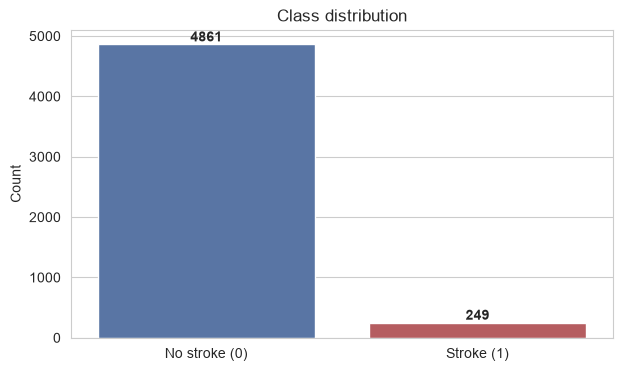


ถ้าทายว่า 'ไม่เป็น' ทุกคน -> Accuracy = 95.1% แต่ Recall ของ stroke = 0
   ต้องดู Recall / F1 / PR-AUC แทน Accuracy และต้องจัดการ imbalance


In [37]:
# === การกระจายตัวของ Class ===
class_counts = df["stroke"].value_counts()
class_ratio = df["stroke"].value_counts(normalize=True) * 100
print(class_counts)
print()
print(class_ratio.round(2))

plt.figure()
sns.barplot(x=["No stroke (0)", "Stroke (1)"], y=class_counts.values,
            hue=["No stroke (0)", "Stroke (1)"], palette=["#4C72B0", "#C44E52"], legend=False)
plt.title("Class distribution")
plt.ylabel("Count")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.savefig(f"{FIG_DIR}/01_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nถ้าทายว่า 'ไม่เป็น' ทุกคน -> Accuracy = {class_ratio[0]:.1f}% แต่ Recall ของ stroke = 0")
print("   ต้องดู Recall / F1 / PR-AUC แทน Accuracy และต้องจัดการ imbalance")

## 5. การกระจายของฟีเจอร์ตัวเลข
### 5.1 Histogram แยกตาม class

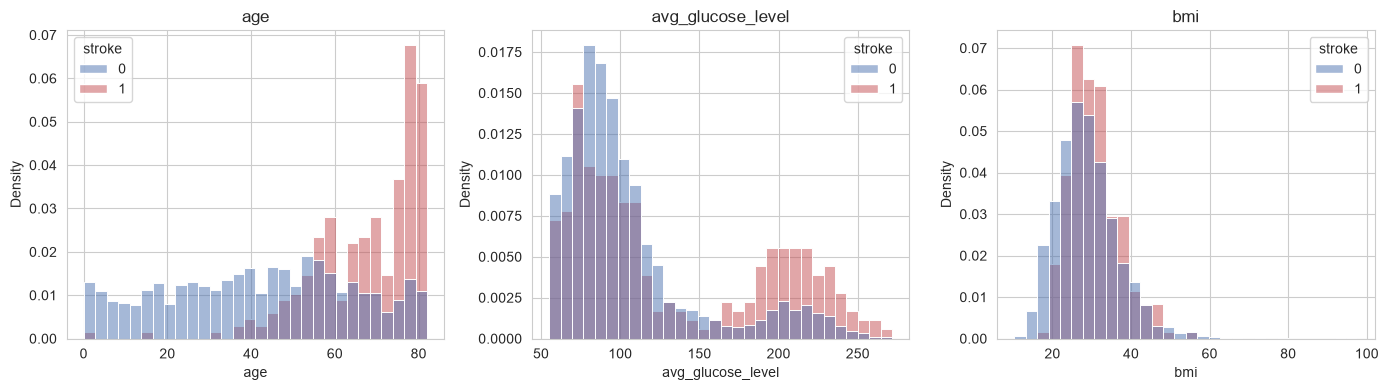

median แยกตาม class:
         age  avg_glucose_level   bmi
stroke                               
0       43.0               91.5  28.0
1       71.0              105.2  29.7


In [38]:
# === การกระจายของฟีเจอร์ตัวเลข แยกตาม class ===
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["age", "avg_glucose_level", "bmi"]):
    sns.histplot(data=df, x=col, hue="stroke", stat="density", common_norm=False,
                 bins=30, palette=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_numeric_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

print("median แยกตาม class:")
print(df.groupby("stroke")[["age", "avg_glucose_level", "bmi"]].median().round(1))

### 5.2 Outliers ด้วยวิธี IQR

age                outliers =    0 แถว | อัตรา stroke ในกลุ่มนี้ = 0.0%
avg_glucose_level  outliers =  627 แถว | อัตรา stroke ในกลุ่มนี้ = 13.4%
bmi                outliers =  110 แถว | อัตรา stroke ในกลุ่มนี้ = 1.8%


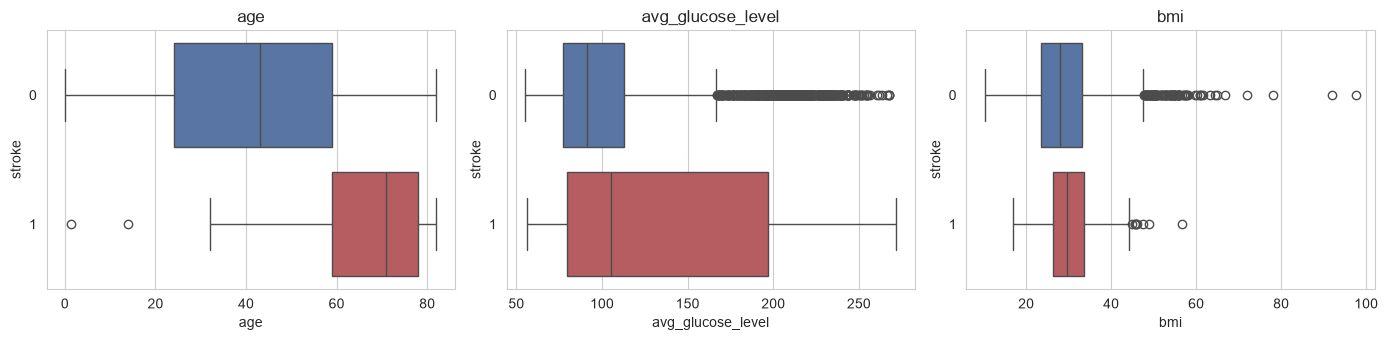

In [39]:
# === Outliers ด้วยวิธี IQR ===
for col in ["age", "avg_glucose_level", "bmi"]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    is_out = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    rate = df.loc[is_out, "stroke"].mean() * 100 if is_out.any() else 0
    print(f"{col:18s} outliers = {is_out.sum():4d} แถว | อัตรา stroke ในกลุ่มนี้ = {rate:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["age", "avg_glucose_level", "bmi"]):
    sns.boxplot(data=df, x=col, y="stroke", orient="h", hue="stroke",
                palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. ปัจจัยที่สัมพันธ์กับ stroke
### 6.1 อัตรา stroke แยกตามกลุ่ม

In [40]:
# === อัตรา stroke แยกตามกลุ่ม ===
df["age_group"] = pd.cut(df["age"], bins=[0, 20, 40, 60, 70, 83],
                         labels=["0-19", "20-39", "40-59", "60-69", "70+"], right=False)

cols = ["age_group", "hypertension", "heart_disease", "ever_married",
        "work_type", "smoking_status", "gender", "Residence_type"]
for col in cols:
    rate = df.groupby(col, observed=True)["stroke"].agg(n="size", rate="mean")
    rate["rate"] = (rate["rate"] * 100).round(1)
    print(f"\n=== {col} ===")
    print(rate)


=== age_group ===
              n  rate
age_group            
0-19        966   0.2
20-39      1204   0.5
40-59      1564   3.8
60-69       621   7.6
70+         755  17.7

=== hypertension ===
                 n  rate
hypertension            
0             4612   4.0
1              498  13.3

=== heart_disease ===
                  n  rate
heart_disease            
0              4834   4.2
1               276  17.0

=== ever_married ===
                 n  rate
ever_married            
No            1757   1.7
Yes           3353   6.6

=== work_type ===
                  n  rate
work_type                
Govt_job        657   5.0
Never_worked     22   0.0
Private        2925   5.1
Self-employed   819   7.9
children        687   0.3

=== smoking_status ===
                    n  rate
smoking_status             
Unknown          1544   3.0
formerly smoked   885   7.9
never smoked     1892   4.8
smokes            789   5.3

=== gender ===
           n  rate
gender            
Female  2

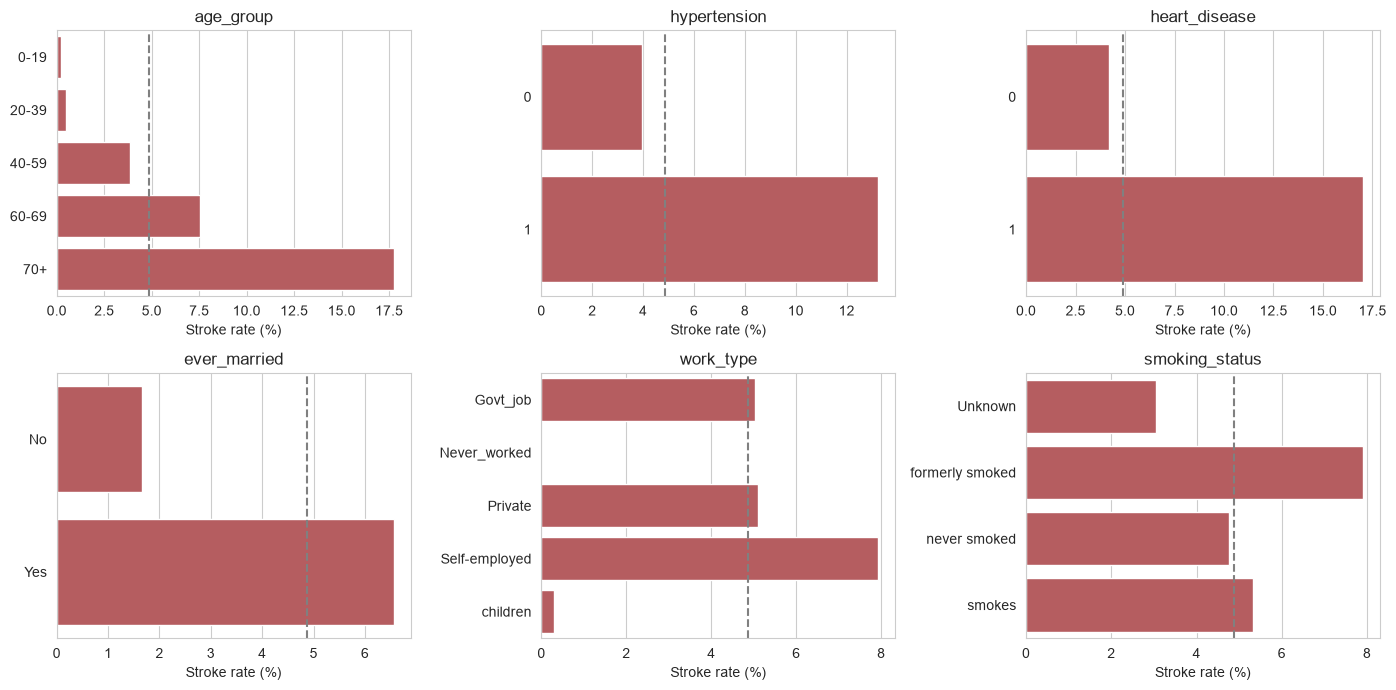

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), cols[:6]):
    rate = df.groupby(col, observed=True)["stroke"].mean() * 100
    sns.barplot(x=rate.values, y=rate.index.astype(str), color="#C44E52", ax=ax)
    ax.axvline(df["stroke"].mean() * 100, color="gray", linestyle="--")   # เส้นค่าเฉลี่ยรวม
    ax.set_title(col)
    ax.set_xlabel("Stroke rate (%)")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_stroke_rate_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.2 Correlation

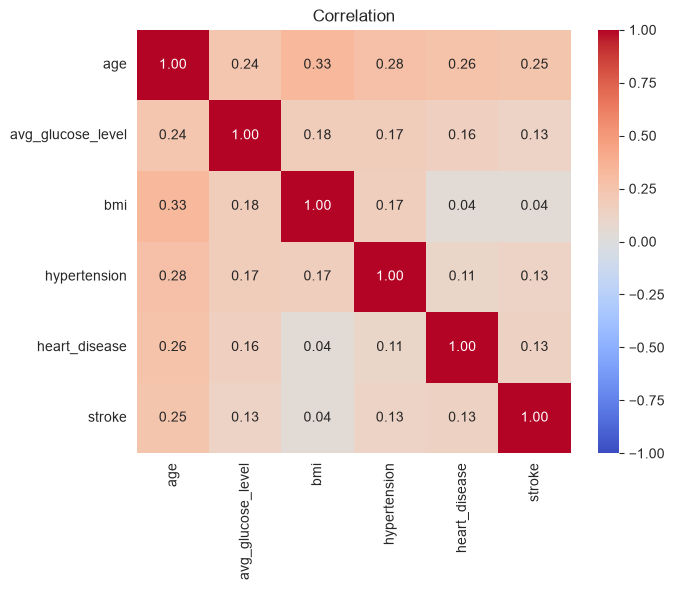

age                  0.25
heart_disease        0.13
avg_glucose_level    0.13
hypertension         0.13
bmi                  0.04
Name: stroke, dtype: float64


In [42]:
# === Correlation ===
corr = df[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation")
plt.savefig(f"{FIG_DIR}/05_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

print(corr["stroke"].drop("stroke").sort_values(ascending=False).round(2))

## 7. สรุป EDA → สิ่งที่จะทำในขั้น Preprocessing

In [43]:
# === สรุป EDA -> สิ่งที่จะทำใน Preprocessing (✏️ กลุ่มปรับถ้อยคำเป็นของตัวเอง) ===
print("1. stroke มีแค่ 4.87% (ไม่สมดุล) -> ใช้ Recall/F1/PR-AUC แทน Accuracy, stratify, ลอง class_weight / SMOTE")
print("2. bmi หาย 201 แถว และแถวที่หายมีอัตรา stroke 19.9% -> ไม่ลบแถว, เติม median + add_indicator")
print("3. smoking_status = Unknown 1,544 แถว (ส่วนใหญ่เป็นเด็ก) -> เก็บเป็นหมวดแยก ไม่ลบ")
print("4. gender = Other มี 1 แถว -> ตัดทิ้ง (ข้อมูลไม่พอทางสถิติ)")
print("5. outlier ของน้ำตาลมีอัตรา stroke 13.4% -> เป็นสัญญาณจริง ไม่ลบ")
print("6. ปัจจัยหลัก: อายุ, โรคหัวใจ, ความดันสูง | gender, Residence_type แทบไม่ต่าง -> ทดลองตัดใน Feature Selection")
print("   ever_married, work_type สัมพันธ์เพราะอายุ (confounder) | ตัด id ออก, one-hot คอลัมน์ข้อความ, scale คอลัมน์ตัวเลข")

1. stroke มีแค่ 4.87% (ไม่สมดุล) -> ใช้ Recall/F1/PR-AUC แทน Accuracy, stratify, ลอง class_weight / SMOTE
2. bmi หาย 201 แถว และแถวที่หายมีอัตรา stroke 19.9% -> ไม่ลบแถว, เติม median + add_indicator
3. smoking_status = Unknown 1,544 แถว (ส่วนใหญ่เป็นเด็ก) -> เก็บเป็นหมวดแยก ไม่ลบ
4. gender = Other มี 1 แถว -> ตัดทิ้ง (ข้อมูลไม่พอทางสถิติ)
5. outlier ของน้ำตาลมีอัตรา stroke 13.4% -> เป็นสัญญาณจริง ไม่ลบ
6. ปัจจัยหลัก: อายุ, โรคหัวใจ, ความดันสูง | gender, Residence_type แทบไม่ต่าง -> ทดลองตัดใน Feature Selection
   ever_married, work_type สัมพันธ์เพราะอายุ (confounder) | ตัด id ออก, one-hot คอลัมน์ข้อความ, scale คอลัมน์ตัวเลข
